In [46]:
"""%pip install ydata-profiling
%pip install pandas matplotlib seaborn scikit-learn keras ipywidgets
%pip install shap
"""

'%pip install ydata-profiling\n%pip install pandas matplotlib seaborn scikit-learn keras ipywidgets\n%pip install shap\n'

In [47]:
%matplotlib inline

# 1- Exploration et préparation des données

In [48]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv("ai4i2020.csv")


In [49]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [50]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [51]:
from ydata_profiling import ProfileReport 
profile = ProfileReport(df, title="Pandas Profiling Report")
profile.to_notebook_iframe()
profile.to_file("output.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 38.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 2- Modélisation avec Autoencodeurs

## Feature engineering

In [52]:
# Features physiques
df['power_kw'] = (df['Torque [Nm]'] * df['Rotational speed [rpm]']) / 9550
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['speed_torque_ratio'] = df['Rotational speed [rpm]'] / (df['Torque [Nm]'] + 1)

# Features d'usure
max_wear = df['Tool wear [min]'].max()
df['wear_level'] = pd.cut(df['Tool wear [min]'], 
                          bins=[0, 80, 160, max_wear + 1],
                          labels=[0, 1, 2],
                          include_lowest=True)
df['wear_level'] = pd.to_numeric(df['wear_level'], errors='coerce').fillna(0).astype(int)

df['high_wear'] = (df['Tool wear [min]'] > 200).astype(int)


# Features d'interaction
df['thermal_load'] = df['temp_diff'] * df['power_kw']
df['mechanical_stress'] = df['Torque [Nm]'] * (1 + df['Tool wear [min]'] / 250)

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['Type'], prefix='Type', drop_first=False)

print(f"\n Feature engineering terminé")
print(f"   Nouvelles features créées : 9")
print(f"   Dataset final : {df_encoded.shape}")



 Feature engineering terminé
   Nouvelles features créées : 9
   Dataset final : (10000, 23)


In [53]:
# ============================================
# DÉFINIR LES FEATURES
# ============================================

features_for_autoencoder = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'power_kw',
    'temp_diff',
    'speed_torque_ratio',
    'wear_level',
    'high_wear',
    'thermal_load',
    'mechanical_stress',
    'Type_H',
    'Type_L',
    'Type_M'
]

print(f"\n Features sélectionnées : {len(features_for_autoencoder)}")


 Features sélectionnées : 15


**ANALYSE DES FEATURES - DISCRIMINATION NORMAUX vs ANOMALIES**

In [54]:
# Séparer normaux et anomalies
df_normal = df_encoded[df_encoded['Machine failure'] == 0]
df_anomaly = df_encoded[df_encoded['Machine failure'] == 1]

print(f"\nNombre de normaux : {len(df_normal)}")
print(f"Nombre d'anomalies : {len(df_anomaly)}")


Nombre de normaux : 9661
Nombre d'anomalies : 339


**STATISTIQUES COMPARATIVES**

In [55]:
from scipy import stats
import numpy as np
import pandas as pd
print("\n" + "="*60)
print("ÉTAPE 1 : COMPARAISON DES MOYENNES")
print("="*60)

features_to_analyze = features_for_autoencoder

results = []

for feature in features_to_analyze:
    mean_normal = df_normal[feature].mean()
    mean_anomaly = df_anomaly[feature].mean()
    std_normal = df_normal[feature].std()
    std_anomaly = df_anomaly[feature].std()
    
    # Différence en %
    if mean_normal != 0:
        diff_pct = ((mean_anomaly - mean_normal) / abs(mean_normal)) * 100
    else:
        diff_pct = 0
    
    # Test statistique (t-test)
    t_stat, p_value = stats.ttest_ind(df_normal[feature], df_anomaly[feature])
    
    # Cohen's d (effect size)
    pooled_std = np.sqrt((std_normal**2 + std_anomaly**2) / 2)
    cohens_d = (mean_anomaly - mean_normal) / pooled_std if pooled_std != 0 else 0
    
    results.append({
        'feature': feature,
        'mean_normal': mean_normal,
        'mean_anomaly': mean_anomaly,
        'diff_pct': diff_pct,
        'cohens_d': abs(cohens_d),
        'p_value': p_value,
        'significant': p_value < 0.05
    })

# Créer DataFrame
df_results = pd.DataFrame(results)

# Trier par Cohen's d (effet le plus fort)
df_results = df_results.sort_values('cohens_d', ascending=False)

print("\n FEATURES TRIÉES PAR POUVOIR DISCRIMINANT (Cohen's d) :")
print("-"*100)
print(f"{'Feature':<30} {'Normal':>10} {'Anomalie':>10} {'Diff %':>8} {'Cohen d':>8} {'p-value':>10} {'Signif':>7}")
print("-"*100)

for _, row in df_results.iterrows():
    signif = " OUI" if row['significant'] else " NON"
    print(f"{row['feature']:<30} {row['mean_normal']:>10.3f} {row['mean_anomaly']:>10.3f} "
          f"{row['diff_pct']:>7.1f}% {row['cohens_d']:>8.3f} {row['p_value']:>10.6f} {signif:>7}")


ÉTAPE 1 : COMPARAISON DES MOYENNES

 FEATURES TRIÉES PAR POUVOIR DISCRIMINANT (Cohen's d) :
----------------------------------------------------------------------------------------------------
Feature                            Normal   Anomalie   Diff %  Cohen d    p-value  Signif
----------------------------------------------------------------------------------------------------
mechanical_stress                  56.485     78.920    39.7%    0.964   0.000000     OUI
Torque [Nm]                        39.630     50.168    26.6%    0.788   0.000000     OUI
high_wear                           0.067      0.348   422.2%    0.739   0.000000     OUI
power_kw                            6.244      7.282    16.6%    0.696   0.000000     OUI
temp_diff                          10.022      9.404    -6.2%    0.572   0.000000     OUI
Tool wear [min]                   106.694    143.782    34.8%    0.545   0.000000     OUI
wear_level                          0.869      1.274    46.7%    0.502   0.

**Choix des 8 meilleurs features selon le Cohen d**

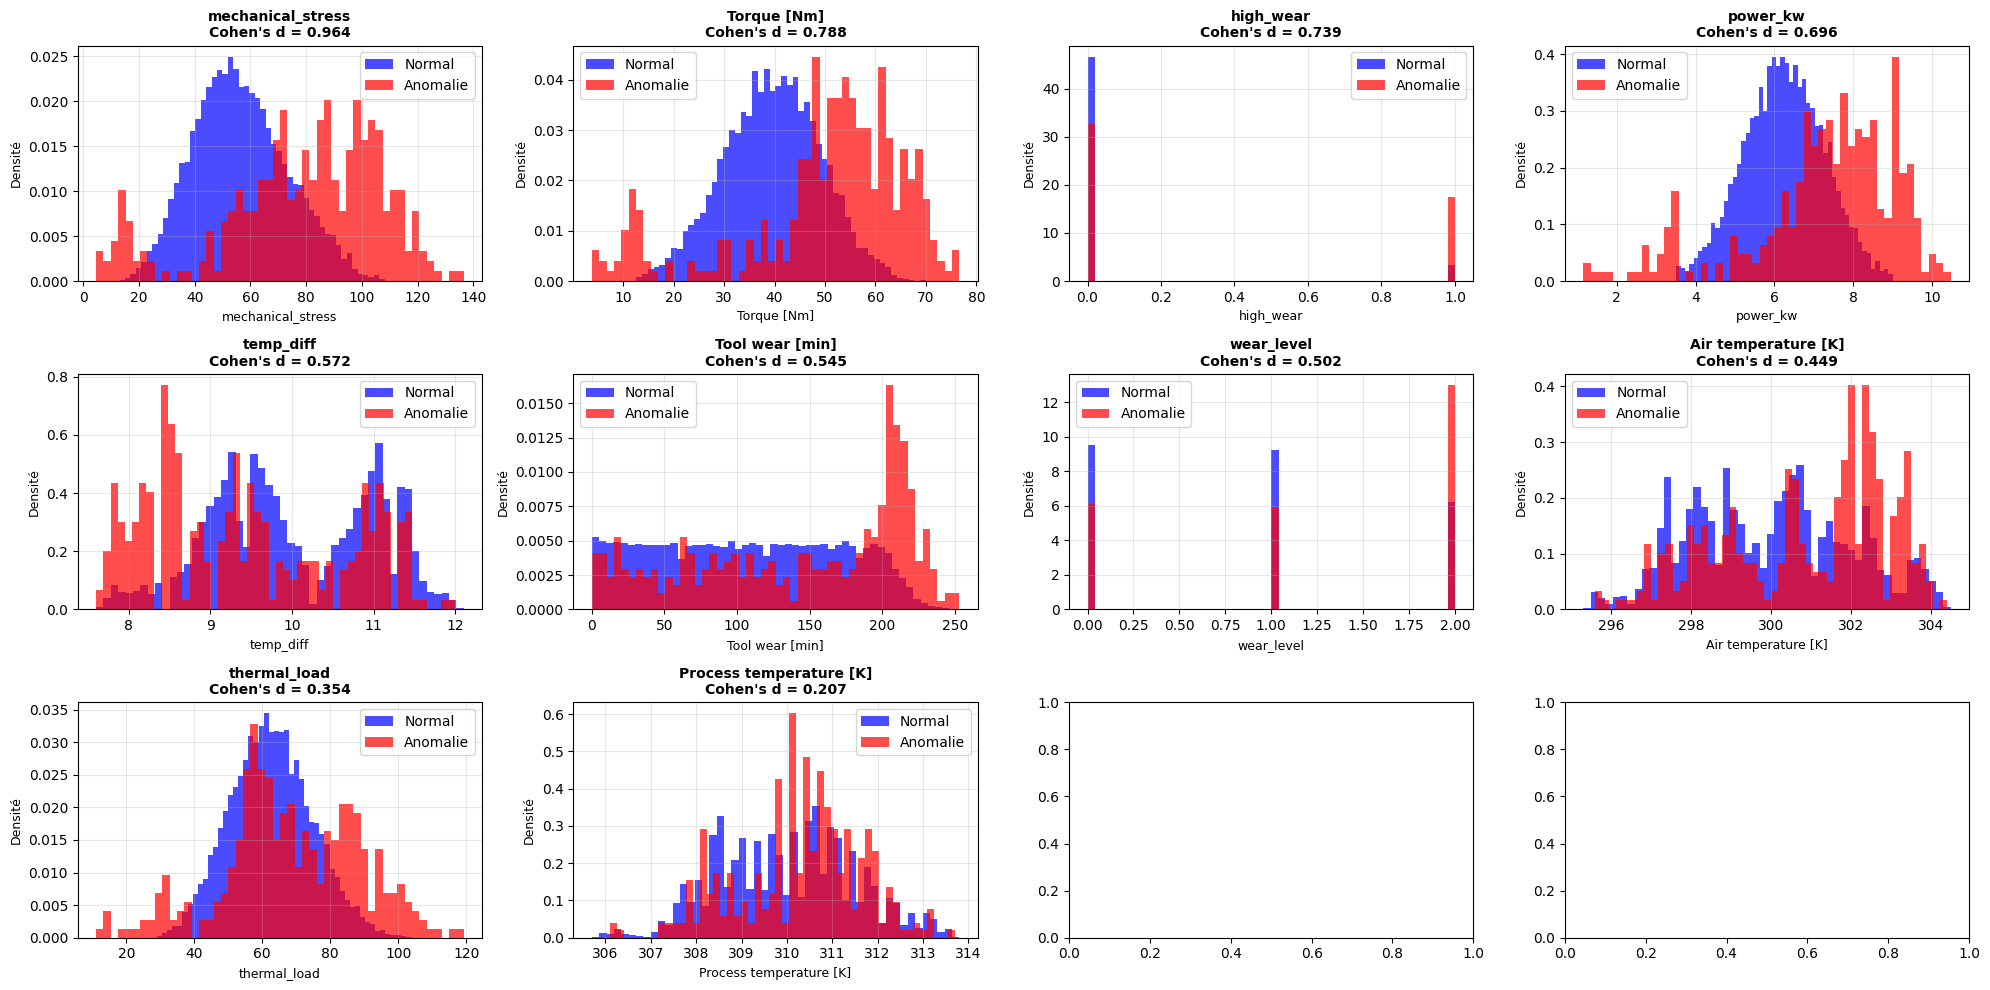

In [56]:
# Prendre les 8 meilleures features
top_features = df_results.head(10)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    # Histogrammes
    axes[i].hist(df_normal[feature], bins=50, alpha=0.7, label='Normal', 
                 color='blue', density=True)
    axes[i].hist(df_anomaly[feature], bins=50, alpha=0.7, label='Anomalie', 
                 color='red', density=True)
    
    # Cohen's d
    cohens_d = df_results[df_results['feature'] == feature]['cohens_d'].values[0]
    
    axes[i].set_title(f'{feature}\nCohen\'s d = {cohens_d:.3f}', 
                     fontweight='bold', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Densité', fontsize=9)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Correlation features et Target**


 CORRÉLATIONS (valeur absolue) :
--------------------------------------------------
mechanical_stress                0.2298
high_wear                        0.1920
Torque [Nm]                      0.1913
power_kw                         0.1760
temp_diff                        0.1117
Tool wear [min]                  0.1054
wear_level                       0.0932
thermal_load                     0.0856
Air temperature [K]              0.0826
speed_torque_ratio               0.0516
Rotational speed [rpm]           0.0442
Process temperature [K]          0.0359
Type_L                           0.0356
Type_H                           0.0239
Type_M                           0.0224


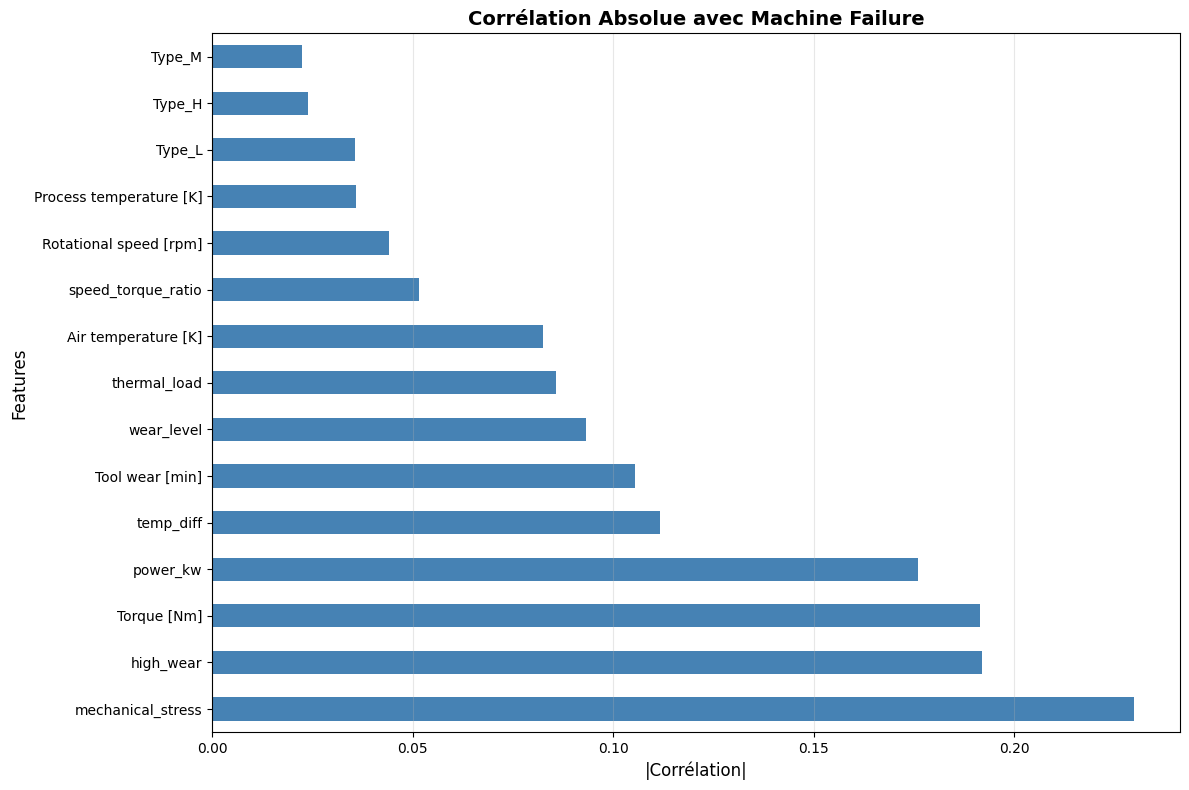

In [57]:
correlations = df_encoded[features_for_autoencoder + ['Machine failure']].corr()['Machine failure'].drop('Machine failure')
correlations_abs = correlations.abs().sort_values(ascending=False)

print("\n CORRÉLATIONS (valeur absolue) :")
print("-"*50)
for feature, corr in correlations_abs.items():
    print(f"{feature:<30} {corr:>8.4f}")

# Visualiser
plt.figure(figsize=(12, 8))
correlations_abs.plot(kind='barh', color='steelblue')
plt.title('Corrélation Absolue avec Machine Failure', fontsize=14, fontweight='bold')
plt.xlabel('|Corrélation|', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**RECOMMANDATION FINALE :  Feature à  conserver**

In [58]:

top_n = 6
top_n_features = df_results.head(top_n)['feature'].tolist()

print(f"\n TOP {top_n} FEATURES RECOMMANDÉES :")
print("="*60)
for i, feat in enumerate(top_n_features, 1):
    cohens_d = df_results[df_results['feature'] == feat]['cohens_d'].values[0]
    corr = correlations_abs[feat]
    print(f"{i:2d}. {feat:<30} | Cohen's d: {cohens_d:.3f} | |Corr|: {corr:.4f}")

print("\n" + "="*60)
print(" ANALYSE TERMINÉE !")
print("="*60)


 TOP 6 FEATURES RECOMMANDÉES :
 1. mechanical_stress              | Cohen's d: 0.964 | |Corr|: 0.2298
 2. Torque [Nm]                    | Cohen's d: 0.788 | |Corr|: 0.1913
 3. high_wear                      | Cohen's d: 0.739 | |Corr|: 0.1920
 4. power_kw                       | Cohen's d: 0.696 | |Corr|: 0.1760
 5. temp_diff                      | Cohen's d: 0.572 | |Corr|: 0.1117
 6. Tool wear [min]                | Cohen's d: 0.545 | |Corr|: 0.1054

 ANALYSE TERMINÉE !


In [59]:
df_results

,feature,mean_normal,mean_anomaly,diff_pct,cohens_d,p_value,significant
11,mechanical_stress,56.485026,78.919895,39.718259,0.963846,5.766052e-120,True
3,Torque [Nm],39.629655,50.168142,26.592425,0.787855,4.573805e-83,True
9,high_wear,0.066660,0.348083,422.177944,0.739288,1.286257e-83,True
5,power_kw,6.244088,7.282283,16.626856,0.696088,2.044216e-70,True
6,temp_diff,10.021571,9.403835,-6.164068,0.571965,4.018489e-29,True
4,Tool wear [min],106.693717,143.781711,34.761179,0.545171,3.976076e-26,True
8,wear_level,0.868544,1.274336,46.721044,0.502483,1.011931e-20,True
0,Air temperature [K],299.973999,300.886431,0.304170,0.449140,1.354800e-16,True
10,thermal_load,62.604540,68.486300,9.395101,0.353579,9.557703e-18,True
1,Process temperature [K],309.995570,310.290265,0.095064,0.206573,3.240058e-04,True


## Entrainement des autoencodeurs

In [ ]:
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("AUTOENCODEUR DENSE - FEATURES OPTIMISÉES")
print("="*60)

# ============================================
# SÉLECTION DES MEILLEURES FEATURES
# ============================================

selected_features = [
    'Tool wear [min]',
    'temp_diff',
    'power_kw',
    'high_wear',
    'Torque [Nm]',
    'mechanical_stress'

]

print(f"\nFeatures sélectionnées : {len(selected_features)}")
for i, feat in enumerate(selected_features, 1):
    cohens_d = df_results[df_results['feature'] == feat]['cohens_d'].values[0]
    print(f"   {i}. {feat:<30} (Cohen's d = {cohens_d:.3f})")

# Créer X et y
X_optimized = df_encoded[selected_features].values
y = df_encoded['Machine failure'].values

print(f"\n Dataset optimisé :")
print(f"   X shape : {X_optimized.shape}")
print(f"   Features : {X_optimized.shape[1]} (au lieu de 15)")
print(f"   Réduction : {(1 - X_optimized.shape[1]/15)*100:.1f}%")

AUTOENCODEUR DENSE - FEATURES OPTIMISÉES

Features sélectionnées : 6
   1. Tool wear [min]                (Cohen's d = 0.545)
   2. temp_diff                      (Cohen's d = 0.572)
   3. power_kw                       (Cohen's d = 0.696)
   4. high_wear                      (Cohen's d = 0.739)
   5. Torque [Nm]                    (Cohen's d = 0.788)
   6. mechanical_stress              (Cohen's d = 0.964)

 Dataset optimisé :
   X shape : (10000, 6)
   Features : 6 (au lieu de 15)
   Réduction : 60.0%


**NORMALISATION**

In [61]:
scaler_opt = StandardScaler()
X_scaled_opt = scaler_opt.fit_transform(X_optimized)

# Séparer normaux pour entraînement
X_normal_opt = X_scaled_opt[y == 0]

# Split train/val
X_train_opt, X_val_opt = train_test_split(X_normal_opt, test_size=0.2, random_state=42)

print(f"\n Données préparées :")
print(f"   Train : {X_train_opt.shape}")
print(f"   Validation : {X_val_opt.shape}") 


 Données préparées :
   Train : (7728, 6)
   Validation : (1933, 6)


In [62]:
import numpy as np
import tensorflow as tf
import random

SEED = 42
# 1. Python random
random.seed(SEED)
# 2. NumPy
np.random.seed(SEED)
# 3. TensorFlow
tf.random.set_seed(SEED)
# 4. Pour reproductibilité complète (optionnel mais recommandé)
import os
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print("Seeds fixés pour reproductibilité")

Seeds fixés pour reproductibilité


In [63]:
input_dim_opt = X_optimized.shape[1]  
encoding_dim = 2  
dropout_rate = 0.3
l1_reg = 1e-5
l2_reg = 0.001
print(f"\n Architecture :")
print(f"   Input : {input_dim_opt} features")
print(f"   Encoding dim : {encoding_dim}")
print(f"   Dropout : {dropout_rate}")
print(f"   L1 regularization : {l1_reg}")
print(f"   L2 regularization : {l2_reg}")
print(f"   Seed : {SEED}")


 Architecture :
   Input : 6 features
   Encoding dim : 2
   Dropout : 0.3
   L1 regularization : 1e-05
   L2 regularization : 0.001
   Seed : 42


In [64]:
# ENCODER
input_layer = keras.layers.Input(shape=(input_dim_opt,))

encoded = keras.layers.Dense(8, activation='relu', 
                             kernel_regularizer=regularizers.l2(l2_reg))(input_layer)
encoded = Dropout(dropout_rate,seed=SEED)(encoded)

encoded = keras.layers.Dense(4, activation='relu',
                             kernel_regularizer=regularizers.l2(l2_reg))(encoded)
encoded = Dropout(dropout_rate,seed=SEED)(encoded)

# Couche latente
encoded = keras.layers.Dense(encoding_dim, activation='relu',
                             activity_regularizer=regularizers.l1(l1_reg),
                             kernel_regularizer=regularizers.l2(l2_reg),name='espace_latent')(encoded)

# DECODER
decoded = keras.layers.Dense(4, activation='relu',
                             )(encoded)

decoded = keras.layers.BatchNormalization()(decoded)


decoded = keras.layers.Dense(8, activation='relu',
                             )(decoded)
                        
decoded = keras.layers.BatchNormalization()(decoded)

decoded = keras.layers.Dense(input_dim_opt, activation='linear')(decoded)

# Modèle
autoencoder_opt = keras.Model(input_layer, decoded)
autoencoder_opt.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

print("\n" + "="*60)
print("ENTRAÎNEMENT")
print("="*60)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)


# Entraîner
history_opt = autoencoder_opt.fit(
    X_train_opt, X_train_opt,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_opt, X_val_opt),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n Entraînement terminé !")
print(f"   Meilleure val_loss : {min(history_opt.history['val_loss']):.6f}")


ENTRAÎNEMENT
Epoch 1/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.2224 - val_loss: 0.8306 - learning_rate: 0.0010
Epoch 2/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7971 - val_loss: 0.6635 - learning_rate: 0.0010
Epoch 3/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7472 - val_loss: 0.6132 - learning_rate: 0.0010
Epoch 4/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6954 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 5/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6673 - val_loss: 0.5489 - learning_rate: 0.0010
Epoch 6/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6443 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 7/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6364 - val_loss: 0.5353 - learning_rate: 0.0010
Epoch 8/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6241 - val_loss: 0.5319 - learning_rate: 0.0010
Epoch 9/200
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6146 - val_loss: 0.5264 - learning_

In [ ]:
import joblib 
autoencoder_opt.save("models/autoencodeur/autoencoder_opt.keras")
joblib.dump(scaler_opt, 'models/autoencodeur/scaler_opt.pkl')

**ÉVALUATION**

In [66]:
# Prédictions
reconstructions_opt = autoencoder_opt.predict(X_scaled_opt, verbose=0)
mse_opt = np.mean(np.square(X_scaled_opt - reconstructions_opt), axis=1)

# Séparer
mse_normal_opt = mse_opt[y == 0]
mse_anomaly_opt = mse_opt[y == 1]

print(f"\n Erreurs de reconstruction :")
print(f"   Normaux - Moyenne : {mse_normal_opt.mean():.6f}")
print(f"   Anomalies - Moyenne : {mse_anomaly_opt.mean():.6f}")
print(f"   Ratio : {mse_anomaly_opt.mean() / mse_normal_opt.mean():.2f}x")


 Erreurs de reconstruction :
   Normaux - Moyenne : 0.256782
   Anomalies - Moyenne : 0.922678
   Ratio : 3.59x


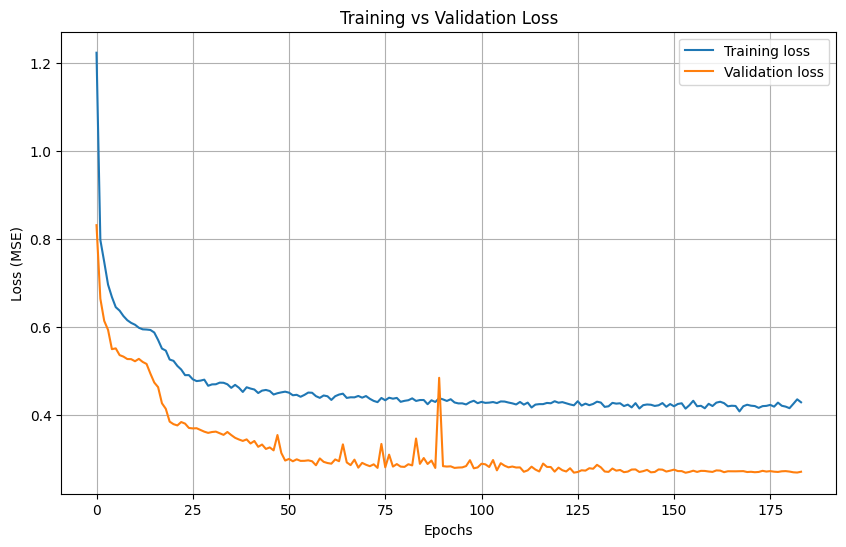

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_opt.history['loss'], label='Training loss')
plt.plot(history_opt.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


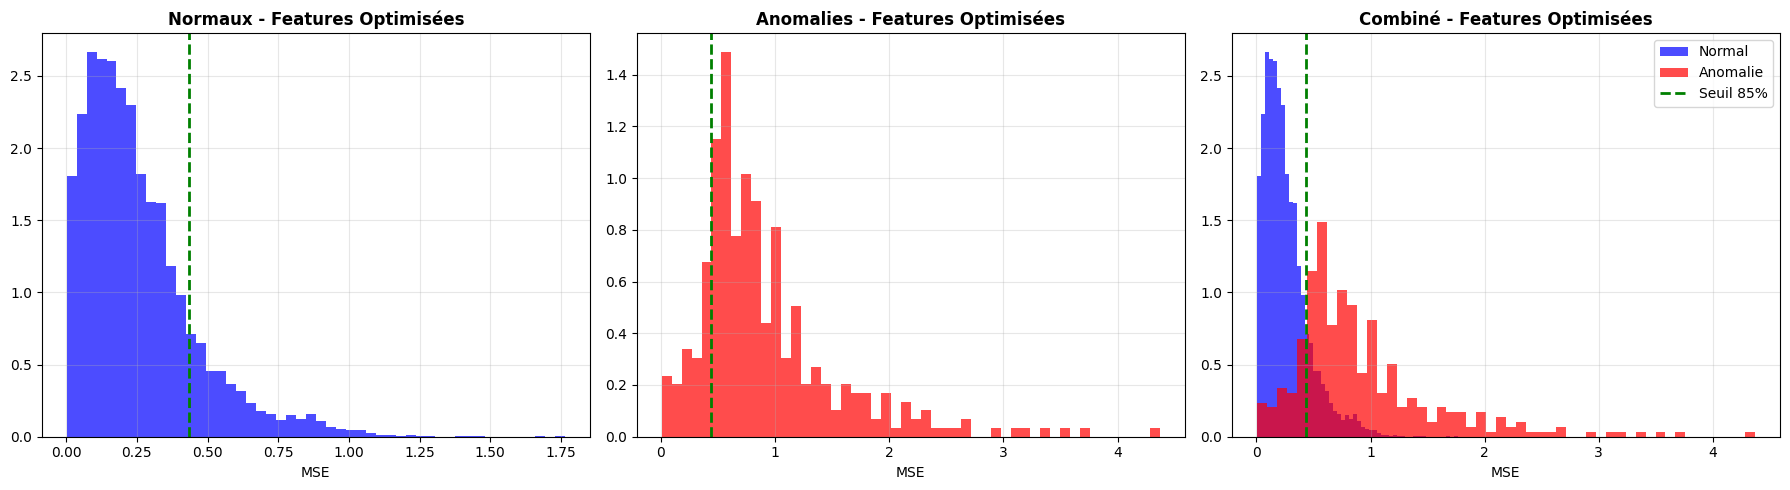

In [68]:
# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(mse_normal_opt, bins=50, alpha=0.7, color='blue', density=True)
axes[0].axvline(np.percentile(mse_normal_opt, 85), color='green', linestyle='--', linewidth=2)
axes[0].set_title('Normaux - Features Optimisées', fontweight='bold')
axes[0].set_xlabel('MSE')
axes[0].grid(True, alpha=0.3)

axes[1].hist(mse_anomaly_opt, bins=50, alpha=0.7, color='red', density=True)
axes[1].axvline(np.percentile(mse_normal_opt, 85), color='green', linestyle='--', linewidth=2)
axes[1].set_title('Anomalies - Features Optimisées', fontweight='bold')
axes[1].set_xlabel('MSE')
axes[1].grid(True, alpha=0.3)

axes[2].hist(mse_normal_opt, bins=50, alpha=0.7, label='Normal', color='blue', density=True)
axes[2].hist(mse_anomaly_opt, bins=50, alpha=0.7, label='Anomalie', color='red', density=True)
axes[2].axvline(np.percentile(mse_normal_opt, 85), color='green', linestyle='--', linewidth=2, label='Seuil 85%')
axes[2].set_title('Combiné - Features Optimisées', fontweight='bold')
axes[2].set_xlabel('MSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Optimisation seuil**

In [69]:

print("\n" + "="*60)
print("OPTIMISATION DU SEUIL")
print("="*60)

for percentile in [70, 75, 80, 85, 90, 95]:
    threshold = np.percentile(mse_normal_opt, percentile)
    predictions = (mse_opt > threshold).astype(int)
    
    recall = recall_score(y, predictions)
    precision = precision_score(y, predictions)
    f1 = f1_score(y, predictions)
    
    print(f"Seuil {percentile:2d}% | Recall: {recall:.3f} | Precision: {precision:.3f} | F1: {f1:.3f}")




OPTIMISATION DU SEUIL
Seuil 70% | Recall: 0.923 | Precision: 0.097 | F1: 0.176
Seuil 75% | Recall: 0.912 | Precision: 0.113 | F1: 0.202
Seuil 80% | Recall: 0.894 | Precision: 0.136 | F1: 0.235
Seuil 85% | Recall: 0.850 | Precision: 0.166 | F1: 0.277
Seuil 90% | Recall: 0.767 | Precision: 0.212 | F1: 0.332
Seuil 95% | Recall: 0.587 | Precision: 0.292 | F1: 0.390



RÉSULTATS FINAUX (Seuil 80%)
              precision    recall  f1-score   support

      Normal       1.00      0.80      0.89      9661
    Anomalie       0.14      0.89      0.24       339

    accuracy                           0.80     10000
   macro avg       0.57      0.85      0.56     10000
weighted avg       0.97      0.80      0.86     10000



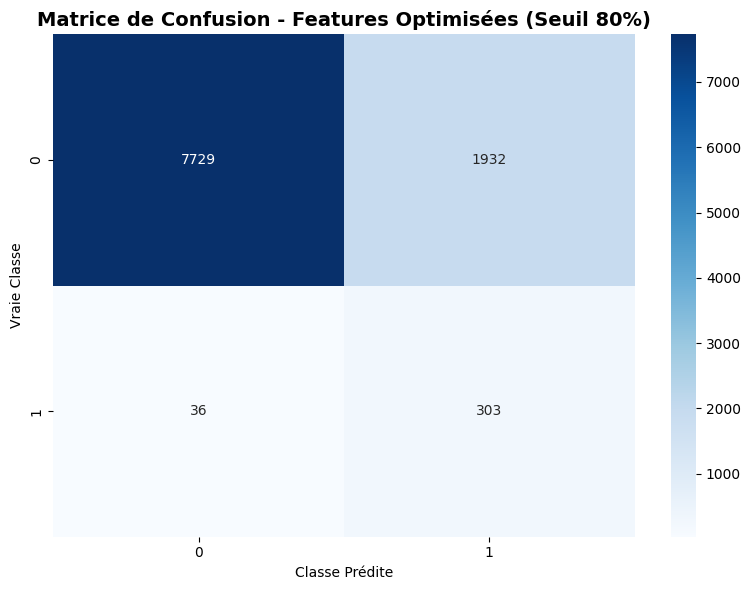


 OPTIMISATION TERMINÉE !


In [70]:
# Meilleur seuil
best_percentile = 80
threshold_best = np.percentile(mse_normal_opt, best_percentile)
predictions_best = (mse_opt > threshold_best).astype(int)

print(f"\n" + "="*60)
print(f"RÉSULTATS FINAUX (Seuil {best_percentile}%)")
print("="*60)

print(classification_report(y, predictions_best, target_names=['Normal', 'Anomalie']))

cm = confusion_matrix(y, predictions_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de Confusion - Features Optimisées (Seuil {best_percentile}%)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.tight_layout()
plt.show()

print("\n OPTIMISATION TERMINÉE !")

## Extraction des représentations latentes

In [71]:
from tensorflow import keras

# Modèle encodeur : entrée → espace latent
encoder = keras.Model(
    inputs=autoencoder_opt.input,
    outputs=autoencoder_opt.get_layer("espace_latent").output
)

encoder.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espace_latent (Dense)           │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102 (408.00 B)

 Trainable params: 102 (408.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
Z = encoder.predict(X_scaled_opt, verbose=0)
print("Espace latent :", Z.shape)

Espace latent : (10000, 2)


Visualisation Comparative de l'Espace Latent

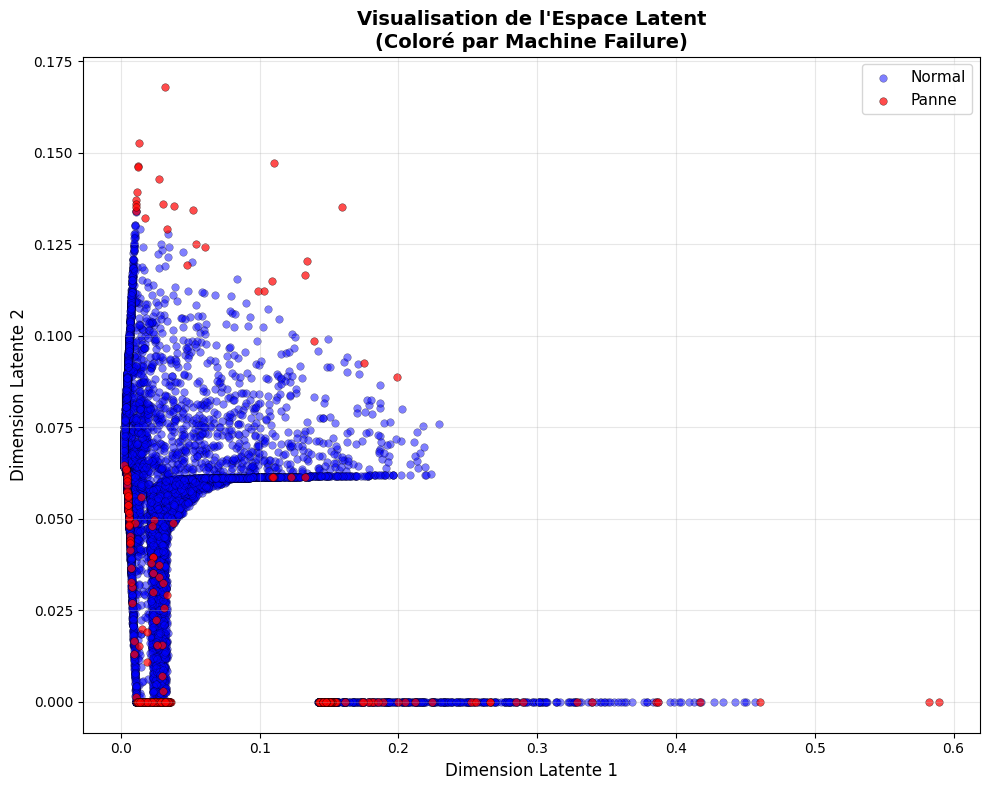

Points normaux (bleu) : 9661
Points en panne (rouge) : 339


In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Visualisation de l'espace latent coloré par Machine Failure
plt.figure(figsize=(10, 8))

# Séparer les points normaux et les pannes pour la légende
normal_mask = (y == 0)
failure_mask = (y == 1)

plt.scatter(Z[normal_mask, 0], Z[normal_mask, 1], 
           c='blue', alpha=0.5, s=30, label='Normal', edgecolors='k', linewidth=0.3)
plt.scatter(Z[failure_mask, 0], Z[failure_mask, 1], 
           c='red', alpha=0.7, s=30, label='Panne', edgecolors='k', linewidth=0.3)

plt.xlabel('Dimension Latente 1', fontsize=12)
plt.ylabel('Dimension Latente 2', fontsize=12)
plt.title('Visualisation de l\'Espace Latent\n(Coloré par Machine Failure)', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques
print(f"Points normaux (bleu) : {normal_mask.sum()}")
print(f"Points en panne (rouge) : {failure_mask.sum()}")

### Clustering

In [74]:
from sklearn.preprocessing import StandardScaler

scaler_latent = StandardScaler()
Z_scaled = scaler_latent.fit_transform(Z)

In [75]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

latent_clusters = kmeans.fit_predict(Z_scaled)


In [76]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(Z_scaled, latent_clusters)

print(f"Silhouette score : {sil_score:.3f}")


Silhouette score : 0.556


In [77]:
cluster_mse = {}
for c in range(3):
    cluster_mse[c] = mse_opt[latent_clusters == c].mean()
    print(f"Cluster {c} | MSE moyenne = {cluster_mse[c]:.6f}")


# Trier par sévérité
sorted_clusters = sorted(cluster_mse, key=cluster_mse.get)
cluster_to_regime = {
    sorted_clusters[0]: "Normal",
    sorted_clusters[1]: "Dégradé",
    sorted_clusters[2]: "En panne"
}
regimes = np.array([cluster_to_regime[c] for c in latent_clusters])
print(cluster_to_regime)


Cluster 0 | MSE moyenne = 0.240880
Cluster 1 | MSE moyenne = 0.320005
Cluster 2 | MSE moyenne = 0.477724
{0: 'Normal', 1: 'Dégradé', 2: 'En panne'}


#### Vérification avec la vérité terrain

In [78]:

df_latent = pd.DataFrame(Z, columns=[f"z{i}" for i in range(Z.shape[1])])
df_latent["cluster"] = latent_clusters
df_latent["regime"] = regimes
df_latent["Machine failure"] = y
df_latent["mse"] = mse_opt

df_latent.groupby(["regime", "Machine failure"]).size()


regime    Machine failure
Dégradé   0                  1875
          1                   150
En panne  0                   827
          1                   121
Normal    0                  6959
          1                    68
dtype: int64

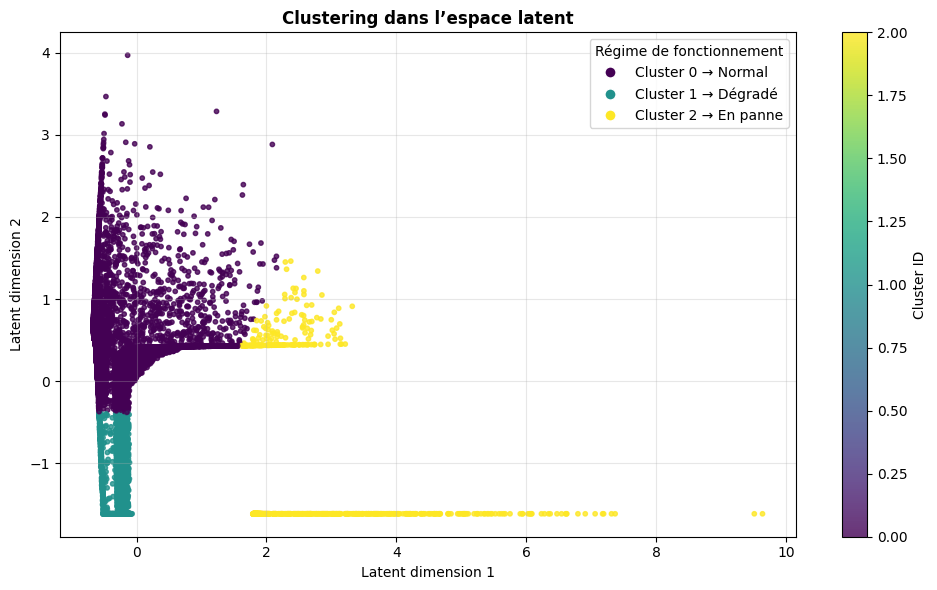

In [79]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    Z_scaled[:, 0],
    Z_scaled[:, 1],
    c=latent_clusters,
    cmap="viridis",
    s=10,
    alpha=0.8
)

plt.title("Clustering dans l’espace latent", fontweight="bold")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.grid(alpha=0.3)

# Colorbar (clusters numériques)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

# ===============================
# LÉGENDE MÉTIER (régimes)
# ===============================

unique_clusters = np.unique(latent_clusters)

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f"Cluster {c} → {cluster_to_regime[c]}",
        markerfacecolor=scatter.cmap(scatter.norm(c)),
        markersize=8
    )
    for c in unique_clusters
]

plt.legend(
    handles=legend_elements,
    title="Régime de fonctionnement",
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()


#### DBSCAN

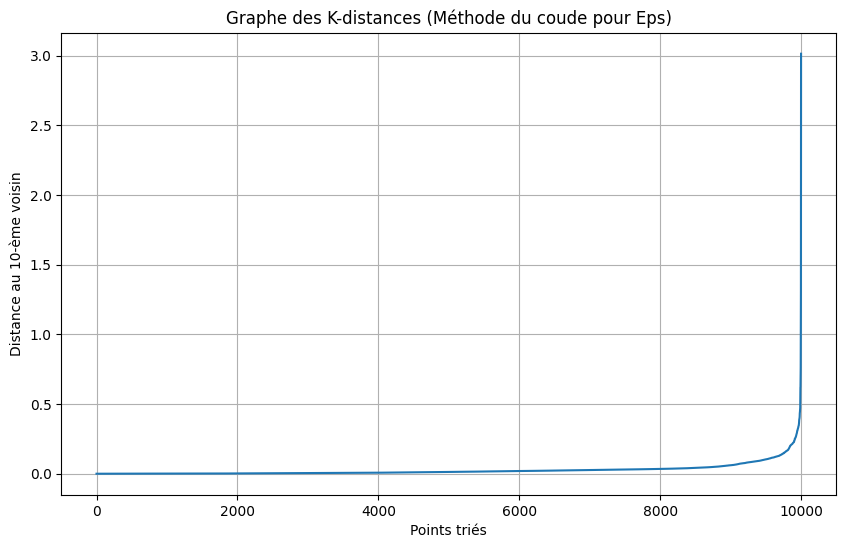

Instruction : Repérez la valeur en ordonnée où la courbe commence à monter brutalement (le coude).


In [80]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Configuration
# "min_samples" définit la densité minimale.
# Règle empirique: 2 * dimensions. Ici dim=2, donc 4.
# On augmente un peu à 10 pour filtrer le bruit plus agressivement.
min_samples = 10

# Calcul des voisins les plus proches
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(Z_scaled)
distances, indices = neighbors_fit.kneighbors(Z_scaled)

# Tri des distances pour afficher le graphe
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Graphe des K-distances (Méthode du coude pour Eps)')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {min_samples}-ème voisin')
plt.grid(True)
plt.show()
print("Instruction : Repérez la valeur en ordonnée où la courbe commence à monter brutalement (le coude).")

In [81]:
# --- PARAMÈTRE A AJUSTER ---
eps_value = 0.5
# ---------------------------

print(f"Lancement de DBSCAN avec eps={eps_value} et min_samples={min_samples}...")
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dbscan_clusters = dbscan.fit_predict(Z_scaled)

# Analyse rapide des résultats
n_clusters_ = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)
n_noise_ = list(dbscan_clusters).count(-1)

print(f'  -> Nombre de clusters estimés : {n_clusters_}')
print(f'  -> Nombre de points de bruit (-1) : {n_noise_}')

Lancement de DBSCAN avec eps=0.5 et min_samples=10...
  -> Nombre de clusters estimés : 2
  -> Nombre de points de bruit (-1) : 5


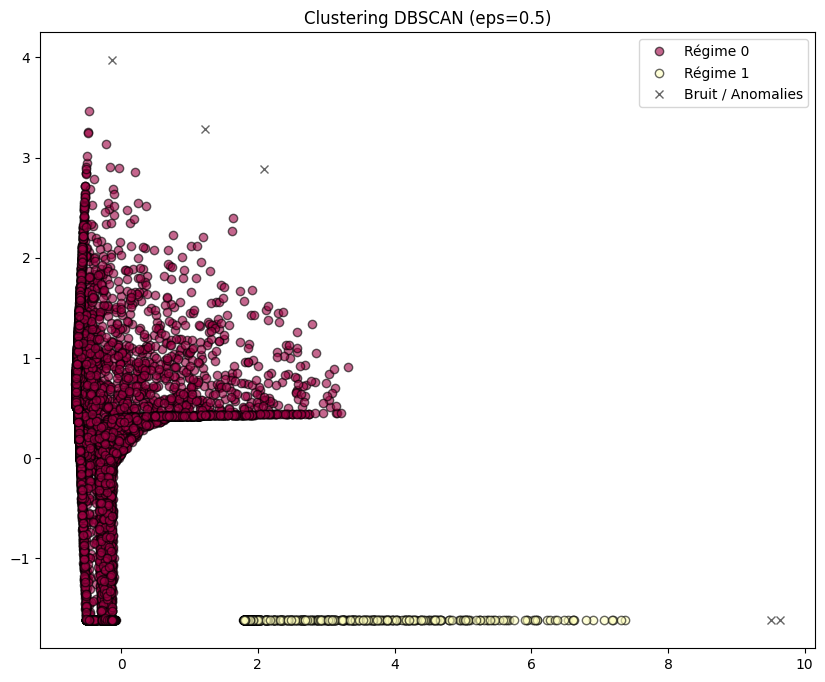

In [82]:
plt.figure(figsize=(10, 8))

unique_labels = set(dbscan_clusters)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Bruit en Noir
        col = [0, 0, 0, 1]
        label = "Bruit / Anomalies"
        marker = 'x'
    else:
        label = f"Régime {k}"
        marker = 'o'

    class_member_mask = (dbscan_clusters == k)

    xy = Z_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6, label=label, alpha=0.6)

plt.title(f'Clustering DBSCAN (eps={eps_value})')
plt.legend()
plt.show()

In [83]:
import pandas as pd

# Création du DataFrame d'analyse
df_dbscan = pd.DataFrame(Z, columns=[f"z{i}" for i in range(Z.shape[1])])
df_dbscan["cluster"] = dbscan_clusters
df_dbscan["Machine failure"] = y
df_dbscan["mse"] = mse_opt

print("=== CARACTÉRISATION DES RÉGIMES (DBSCAN) ===")
print(f"{'Cluster':<15} | {'Count':<8} | {'MSE Moyen':<10} | {'Taux de Panne (%)':<20} | {'Interprétation probable'}")
print("-" * 85)

for c in sorted(unique_labels):
    mask = df_dbscan["cluster"] == c
    avg_mse = df_dbscan.loc[mask, "mse"].mean()
    fail_rate = df_dbscan.loc[mask, "Machine failure"].mean() * 100
    count = mask.sum()

    # Logique simple d'interprétation
    if c == -1:
        interp = "ANOMALIE (Non modélisé)"
    elif avg_mse < np.percentile(mse_opt, 80): # 
        interp = "NORMAL"
    else:
        interp = "DÉGRADÉ / PANNE"

    print(f"{c:<15} | {count:<8} | {avg_mse:.4f}     | {fail_rate:6.2f}%            | {interp}")

=== CARACTÉRISATION DES RÉGIMES (DBSCAN) ===
Cluster         | Count    | MSE Moyen  | Taux de Panne (%)    | Interprétation probable
-------------------------------------------------------------------------------------
-1              | 5        | 1.5982     | 100.00%            | ANOMALIE (Non modélisé)
0               | 9235     | 0.2614     |   2.36%            | NORMAL
1               | 760      | 0.4893     |  15.26%            | DÉGRADÉ / PANNE


# 3- Comparaison avec les méthodes classiques

## Isolation forest

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [85]:

features = ['Tool wear [min]','temp_diff','power_kw','high_wear','Torque [Nm]','mechanical_stress']

X = df[features]
y = df['Machine failure']  


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données chargées : {X_scaled.shape}")
print(f"Répartition des classes : \n{y.value_counts()}")

Données chargées : (10000, 6)
Répartition des classes : 
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [86]:
# Configuration du modèle
# contamination=0.03 : On s'attend à environ 3% d'anomalies (correspondant à votre dataset)
iso_forest = IsolationForest(
    n_estimators=100,        # Nombre d'arbres
    max_samples=256,         # Échantillon par arbre (évite de "noyer" les anomalies)
    contamination=0.03,      # Proportion estimée d'anomalies
    random_state=42,
    n_jobs=-1                
)

# Entraînement et prédiction
# Note : Isolation Forest renvoie 1 (Normal) et -1 (Anomalie)
print("Entraînement en cours...")
predictions_if = iso_forest.fit_predict(X_scaled)

print(" Entraînement terminé.")

Entraînement en cours...
 Entraînement terminé.


In [87]:
import joblib
joblib.dump(iso_forest, 'models/isolation_forest/isolation_forest.pkl')
joblib.dump(scaler, 'models/isolation_forest/scaler.pkl')

print("Modèle et Scaler sauvegardés")



Modèle et Scaler sauvegardés


RÉSULTATS ISOLATION FOREST
Matrice de Confusion :
 [[9503  158]
 [ 197  142]]

- Pannes détectées (TP) : 142
- Pannes ratées (FN)    : 197
- Fausses alarmes (FP)  : 158


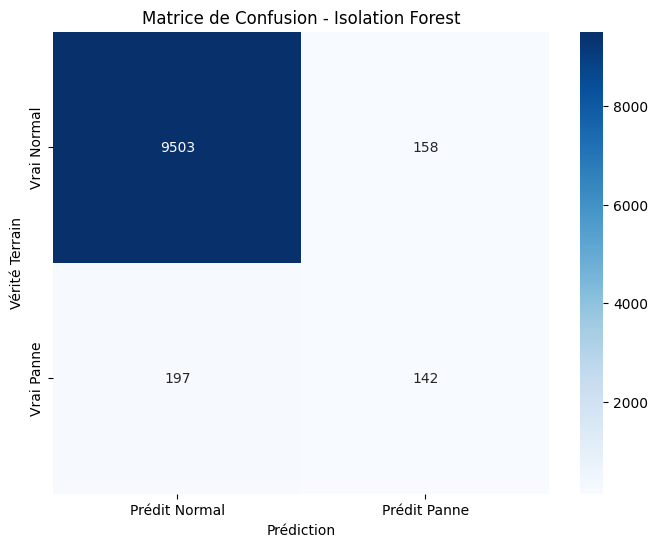

ROC AUC Score : 0.9196


In [88]:
# Conversion des prédictions pour match vos labels :
y_pred_if = np.where(predictions_if == -1, 1, 0)

# Matrice de Confusion
print("="*60)
print("RÉSULTATS ISOLATION FOREST")
print("="*60)
cm = confusion_matrix(y, y_pred_if)
print("Matrice de Confusion :\n", cm)

# Affichage détaillé
tn, fp, fn, tp = cm.ravel()
print(f"\n- Pannes détectées (TP) : {tp}")
print(f"- Pannes ratées (FN)    : {fn}")
print(f"- Fausses alarmes (FP)  : {fp}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Normal', 'Prédit Panne'],
            yticklabels=['Vrai Normal', 'Vrai Panne'])
plt.title('Matrice de Confusion - Isolation Forest')
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction')
plt.show()

# Score ROC AUC
scores_if = iso_forest.decision_function(X_scaled)
auc = roc_auc_score(y, -scores_if) # On inverse car score bas = anomalie
print(f"ROC AUC Score : {auc:.4f}")

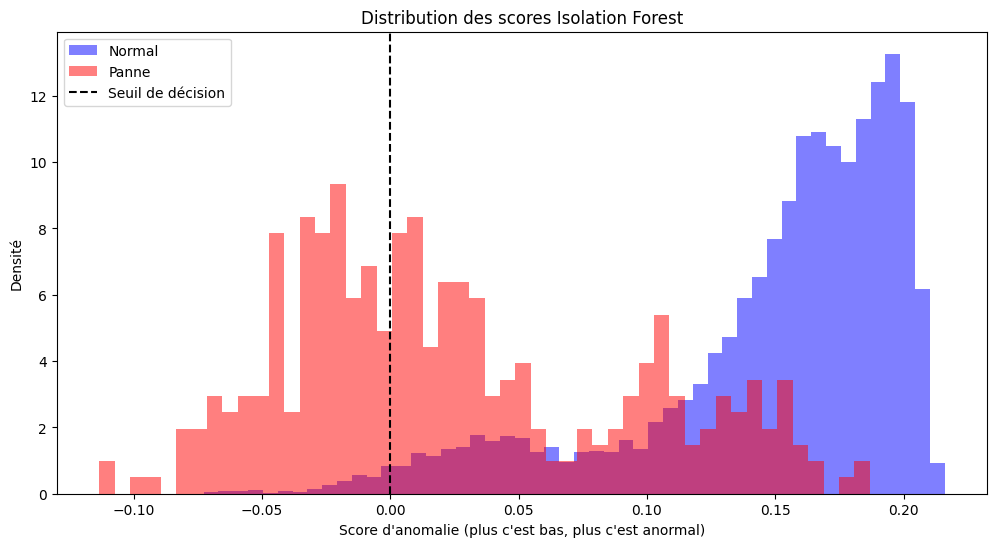

In [89]:
plt.figure(figsize=(12, 6))

# Histogramme des scores
plt.hist(scores_if[y==0], bins=50, alpha=0.5, label="Normal", color="blue", density=True)
plt.hist(scores_if[y==1], bins=50, alpha=0.5, label="Panne", color="red", density=True)

plt.axvline(0, color='k', linestyle='--', label="Seuil de décision")
plt.xlabel("Score d'anomalie (plus c'est bas, plus c'est anormal)")
plt.ylabel("Densité")
plt.title("Distribution des scores Isolation Forest")
plt.legend()
plt.show()

## One Class SVM

In [90]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [91]:

features = ['Tool wear [min]','temp_diff','power_kw','high_wear','Torque [Nm]','mechanical_stress']

X = df[features]
y = df['Machine failure']  # 0=Normal, 1=Panne

# Normalisation (CRUCIALE pour One-Class SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données chargées : {X_scaled.shape}")
print(f"Taux de pannes : {y.mean()*100:.2f}%")

Données chargées : (10000, 6)
Taux de pannes : 3.39%


In [92]:

ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.03
)

print("Entraînement One-Class SVM en cours...")


# Entraînement
ocsvm.fit(X_scaled)

print(" Entraînement terminé")

Entraînement One-Class SVM en cours...
 Entraînement terminé


In [93]:
import joblib
import os

os.makedirs('models/one_class_svm', exist_ok=True)

joblib.dump(ocsvm, 'models/one_class_svm/ocsvm.pkl')
joblib.dump(scaler, 'models/one_class_svm/scaler.pkl')

print(" Modèle One-Class SVM et Scaler sauvegardés dans models/one_class_svm/")

 Modèle One-Class SVM et Scaler sauvegardés dans models/one_class_svm/


In [94]:
# Prédiction
# OCSVM retourne : +1 (normal), -1 (anomalie)
predictions_ocsvm = ocsvm.predict(X_scaled)

# Conversion pour correspondre à nos labels
# Nos labels : 0=Normal, 1=Panne
y_pred_ocsvm = np.where(predictions_ocsvm == -1, 1, 0)

print(f"Nombre d'anomalies détectées : {(y_pred_ocsvm == 1).sum()}")

Nombre d'anomalies détectées : 296


In [95]:
print("="*60)
print("RÉSULTATS ONE-CLASS SVM")
print("="*60)

cm_ocsvm = confusion_matrix(y, y_pred_ocsvm)
print("Matrice de Confusion :")
print(cm_ocsvm)

tn, fp, fn, tp = cm_ocsvm.ravel()
print(f"\n- Pannes détectées (TP) : {tp}")
print(f"- Pannes ratées (FN)    : {fn}")
print(f"- Fausses alarmes (FP)  : {fp}")

# Rapport complet
print("\n" + classification_report(y, y_pred_ocsvm, 
                                  target_names=['Normal', 'Panne']))

RÉSULTATS ONE-CLASS SVM
Matrice de Confusion :
[[9466  195]
 [ 238  101]]

- Pannes détectées (TP) : 101
- Pannes ratées (FN)    : 238
- Fausses alarmes (FP)  : 195

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      9661
       Panne       0.34      0.30      0.32       339

    accuracy                           0.96     10000
   macro avg       0.66      0.64      0.65     10000
weighted avg       0.95      0.96      0.96     10000



In [96]:
# Récupération des scores bruts
# Plus le score est négatif, plus c'est une anomalie
scores_ocsvm = ocsvm.decision_function(X_scaled)

# Calcul du ROC AUC (on inverse les scores)
auc_ocsvm = roc_auc_score(y, -scores_ocsvm)

print(f"ROC AUC Score : {auc_ocsvm:.4f}")
print(f"\nScore min (anomalie forte) : {scores_ocsvm.min():.4f}")
print(f"Score max (normal fort)    : {scores_ocsvm.max():.4f}")

ROC AUC Score : 0.8014

Score min (anomalie forte) : -18.2933
Score max (normal fort)    : 6.5689


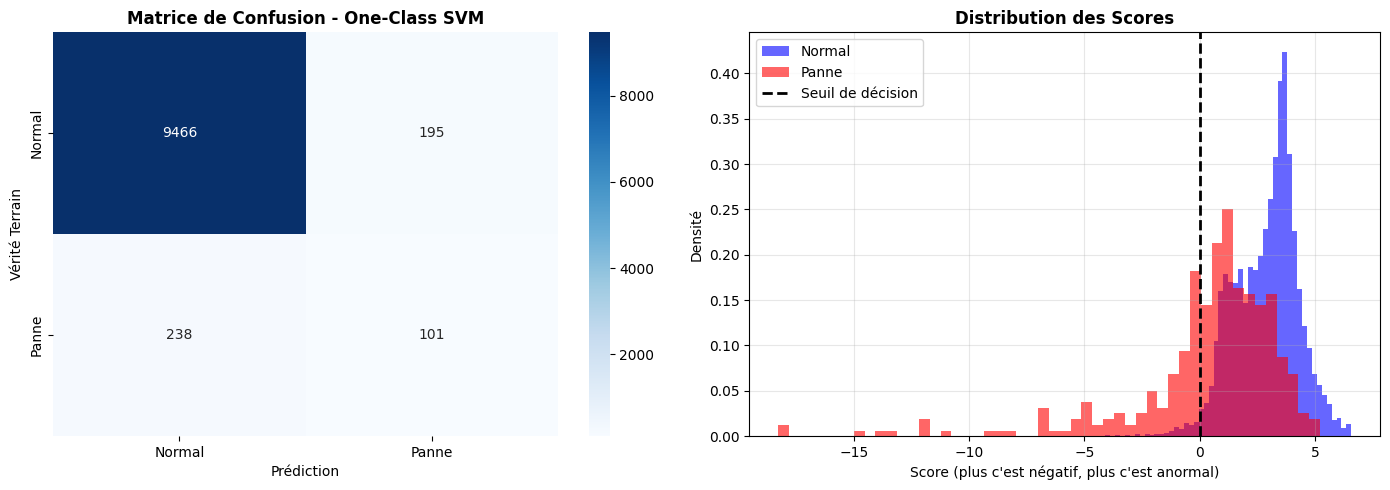

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Matrice de confusion
sns.heatmap(cm_ocsvm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Panne'], 
            yticklabels=['Normal', 'Panne'])
axes[0].set_title('Matrice de Confusion - One-Class SVM', fontweight='bold')
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédiction')

# Graphique 2 : Distribution des scores
axes[1].hist(scores_ocsvm[y==0], bins=50, alpha=0.6, 
             label='Normal', color='blue', density=True)
axes[1].hist(scores_ocsvm[y==1], bins=50, alpha=0.6, 
             label='Panne', color='red', density=True)
axes[1].axvline(0, color='k', linestyle='--', linewidth=2, 
                label='Seuil de décision')
axes[1].set_xlabel('Score (plus c\'est négatif, plus c\'est anormal)')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution des Scores', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Local Outlier Factor

In [98]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [99]:
features = ['Tool wear [min]','temp_diff','power_kw','high_wear','Torque [Nm]','mechanical_stress']

X = df[features]
y = df['Machine failure']  # 0=Normal, 1=Panne

# Normalisation (importante pour les méthodes basées sur la distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données chargées : {X_scaled.shape}")
print(f"Taux de pannes : {y.mean()*100:.2f}%")

Données chargées : (10000, 6)
Taux de pannes : 3.39%


In [100]:

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03,
    n_jobs=-1
)

print("Calcul du LOF en cours...")

# fit_predict : entraîne et prédit en une seule étape
# Retourne : +1 (normal), -1 (anomalie)
predictions_lof = lof.fit_predict(X_scaled)

print("Calcul terminé")

Calcul du LOF en cours...
Calcul terminé


In [101]:
os.makedirs('models/lof', exist_ok=True)
joblib.dump(lof, 'models/lof/lof.pkl')
joblib.dump(scaler, 'models/lof/scaler.pkl')
print("Modèle LOF et Scaler sauvegardés dans models/lof/")

Modèle LOF et Scaler sauvegardés dans models/lof/


In [102]:
# Conversion pour correspondre à nos labels
# Nos labels : 0=Normal, 1=Panne
y_pred_lof = np.where(predictions_lof == -1, 1, 0)

# Extraction des scores LOF
# negative_outlier_factor_ : plus c'est négatif, plus c'est une anomalie
# On inverse le signe pour avoir : score élevé = anomalie
lof_scores = -lof.negative_outlier_factor_

print(f"Nombre d'anomalies détectées : {(y_pred_lof == 1).sum()}")
print(f"\nScore LOF min (normal) : {lof_scores.min():.4f}")
print(f"Score LOF max (anomalie forte) : {lof_scores.max():.4f}")
print(f"Score LOF moyen : {lof_scores.mean():.4f}")

Nombre d'anomalies détectées : 300

Score LOF min (normal) : 0.9433
Score LOF max (anomalie forte) : 2.5667
Score LOF moyen : 1.0399


In [103]:
print("="*60)
print("RÉSULTATS LOCAL OUTLIER FACTOR (LOF)")
print("="*60)

cm_lof = confusion_matrix(y, y_pred_lof)
print("Matrice de Confusion :")
print(cm_lof)

tn, fp, fn, tp = cm_lof.ravel()
print(f"\n- Pannes détectées (TP) : {tp}")
print(f"- Pannes ratées (FN)    : {fn}")
print(f"- Fausses alarmes (FP)  : {fp}")

# Rapport complet
print("\n" + classification_report(y, y_pred_lof, 
                                  target_names=['Normal', 'Panne']))

RÉSULTATS LOCAL OUTLIER FACTOR (LOF)
Matrice de Confusion :
[[9452  209]
 [ 248   91]]

- Pannes détectées (TP) : 91
- Pannes ratées (FN)    : 248
- Fausses alarmes (FP)  : 209

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      9661
       Panne       0.30      0.27      0.28       339

    accuracy                           0.95     10000
   macro avg       0.64      0.62      0.63     10000
weighted avg       0.95      0.95      0.95     10000



In [104]:
# Calcul du ROC AUC avec les scores continus
auc_lof = roc_auc_score(y, lof_scores)

print(f"ROC AUC Score : {auc_lof:.4f}")

# Statistiques par classe
print(f"\nScore LOF moyen pour les normaux : {lof_scores[y==0].mean():.4f}")
print(f"Score LOF moyen pour les pannes  : {lof_scores[y==1].mean():.4f}")

ROC AUC Score : 0.8218

Score LOF moyen pour les normaux : 1.0349
Score LOF moyen pour les pannes  : 1.1830


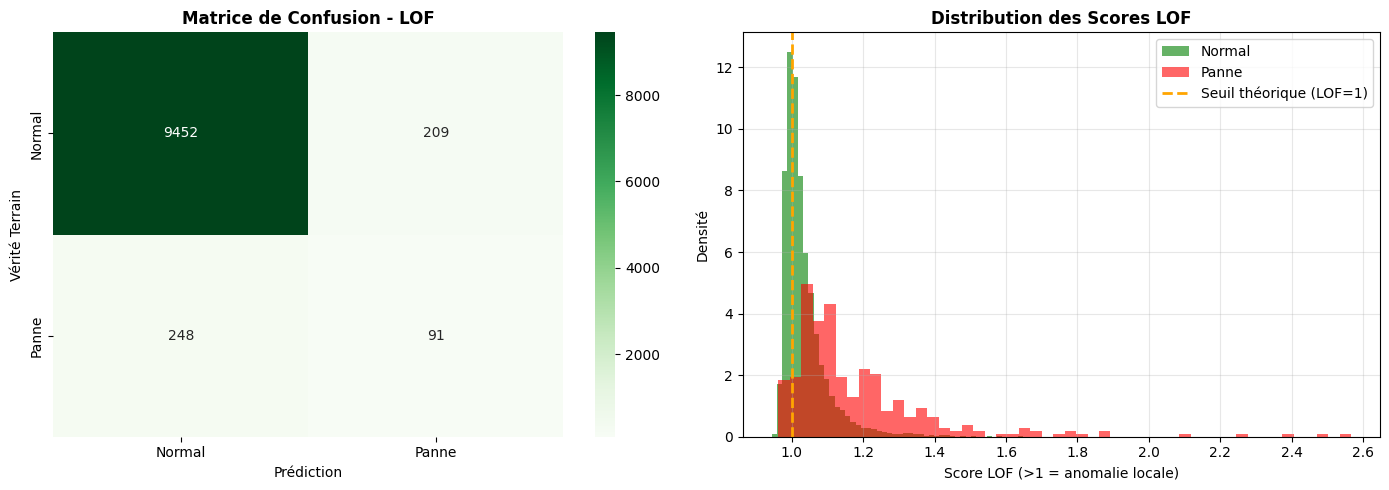

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Matrice de confusion
sns.heatmap(cm_lof, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Panne'], 
            yticklabels=['Normal', 'Panne'])
axes[0].set_title('Matrice de Confusion - LOF', fontweight='bold')
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédiction')

# Graphique 2 : Distribution des scores LOF
axes[1].hist(lof_scores[y==0], bins=50, alpha=0.6, 
             label='Normal', color='green', density=True)
axes[1].hist(lof_scores[y==1], bins=50, alpha=0.6, 
             label='Panne', color='red', density=True)
axes[1].axvline(1.0, color='orange', linestyle='--', linewidth=2, 
                label='Seuil théorique (LOF=1)')
axes[1].set_xlabel('Score LOF (>1 = anomalie locale)')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution des Scores LOF', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## LSTM

In [115]:
import pandas as pd
df=pd.read_csv("ai4i2020.csv")

In [116]:
# Features physiques
df['power_kw'] = (df['Torque [Nm]'] * df['Rotational speed [rpm]']) / 9550
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['speed_torque_ratio'] = df['Rotational speed [rpm]'] / (df['Torque [Nm]'] + 1)

# Features d'usure
max_wear = df['Tool wear [min]'].max()
df['wear_level'] = pd.cut(df['Tool wear [min]'], 
                          bins=[0, 80, 160, max_wear + 1],
                          labels=[0, 1, 2],
                          include_lowest=True)
df['wear_level'] = pd.to_numeric(df['wear_level'], errors='coerce').fillna(0).astype(int)

df['high_wear'] = (df['Tool wear [min]'] > 200).astype(int)


# Features d'interaction
df['thermal_load'] = df['temp_diff'] * df['power_kw']
df['mechanical_stress'] = df['Torque [Nm]'] * (1 + df['Tool wear [min]'] / 250)

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['Type'], prefix='Type', drop_first=False)

print(f"\n Feature engineering terminé")
print(f"   Nouvelles features créées : 9")
print(f"   Dataset final : {df_encoded.shape}")



 Feature engineering terminé
   Nouvelles features créées : 9
   Dataset final : (10000, 23)


In [117]:
features_for_autoencoder = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'power_kw',
    'temp_diff',
    'speed_torque_ratio',
    'wear_level',
    'high_wear',
    'thermal_load',
    'mechanical_stress',
]
print(f"\n Features sélectionnées : {len(features_for_autoencoder)}")


 Features sélectionnées : 12


In [118]:
import pandas as pd

df_encoded["Time_ID"] = ["T" + str(i) for i in range(1, len(df) + 1)]

df_encoded.head()

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,power_kw,temp_diff,speed_torque_ratio,wear_level,high_wear,thermal_load,mechanical_stress,Type_H,Type_L,Type_M,Time_ID
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,6.951079,10.5,35.410959,0,0,72.986325,42.8000,False,False,True,T1
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,6.826220,10.5,29.767442,0,0,71.675309,46.8556,False,True,False,T2
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,7.748817,10.4,29.722222,0,0,80.587694,50.3880,False,True,False,T3
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,5.927068,10.4,35.382716,0,0,61.641508,40.6060,False,True,False,T4
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,5.897382,10.5,34.341463,0,0,61.922513,41.4400,False,True,False,T5


In [147]:
df_encoded_normal=df_encoded[df_encoded['Machine failure']==0][features_for_autoencoder]
df_encoded_anomaly=df_encoded[df_encoded['Machine failure']==1][features_for_autoencoder]


In [148]:
df_encoded_normal.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],power_kw,temp_diff,speed_torque_ratio,wear_level,high_wear,thermal_load,mechanical_stress
0,298.1,308.6,1551,42.8,0,6.951079,10.5,35.410959,0,0,72.986325,42.8000
1,298.2,308.7,1408,46.3,3,6.826220,10.5,29.767442,0,0,71.675309,46.8556
2,298.1,308.5,1498,49.4,5,7.748817,10.4,29.722222,0,0,80.587694,50.3880
3,298.2,308.6,1433,39.5,7,5.927068,10.4,35.382716,0,0,61.641508,40.6060
4,298.2,308.7,1408,40.0,9,5.897382,10.5,34.341463,0,0,61.922513,41.4400


In [168]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_normal_scaled = scaler.fit_transform(df_encoded_normal)
X_anomaly_scaled = scaler.transform(df_encoded_anomaly)


In [169]:
def create_sequences(X, timesteps):
    sequences = []
    for i in range(len(X) - timesteps + 1):
        sequences.append(X[i:i+timesteps])
    return np.array(sequences)

timesteps = 20  # IMPORTANT : fixe-le explicitement

X_normal_seq = create_sequences(X_normal_scaled, timesteps)
X_anomaly_seq = create_sequences(X_anomaly_scaled, timesteps)

print(X_normal_seq.shape, X_anomaly_seq.shape)


(9642, 20, 12) (320, 20, 12)


In [152]:
print(features)

12


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, RepeatVector,
    TimeDistributed, Dense, Dropout
)

timesteps = X_seq.shape[1]   
features = X_seq.shape[2]    

inputs = Input(shape=(timesteps, features))

# ================= ENCODER =================
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)

x = LSTM(32, return_sequences=False)(x)

# Latent space (compression forte)
latent = Dense(16, activation="relu")(x)

# ================= DECODER =================
x = RepeatVector(timesteps)(latent)

x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.2)(x)

x = LSTM(64, return_sequences=True)(x)

outputs = TimeDistributed(Dense(features))(x)

# ================= MODEL =================
autoencoder = Model(inputs, outputs)
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 20, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 20, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 20, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 20, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 20, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 12)         │           780 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,540 (252.11 KB)

 Trainable params: 64,540 (252.11 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
history = autoencoder.fit(
    X_seq, X_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False  # important pour les séries temporelles
)


Epoch 1/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - loss: 0.0390 - val_loss: 0.0300
Epoch 2/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - loss: 0.0248 - val_loss: 0.0234
Epoch 3/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0206 - val_loss: 0.0209
Epoch 4/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0193 - val_loss: 0.0188
Epoch 5/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 0.0187 - val_loss: 0.0172
Epoch 6/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0183 - val_loss: 0.0164
Epoch 7/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0181 - val_loss: 0.0182
Epoch 8/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - loss: 0.0184 - val_loss: 0.0164
Epoch 9/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0183 - val_loss: 0.0157
Epoch 10/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0185 - val_loss: 0.0175
Epoch 11/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0185 - val_loss: 0.0160
Epoch 12/30
272/272 ━━━━━━━━━━

In [232]:
#sauvegarde du model
import joblib
autoencoder.save('models/autoencodeur_lstm/autoencoder_lstm.keras')
joblib.dump(scaler, 'models/autoencodeur_lstm/scaler.pkl')

['models/autoencodeur_lstm/scaler.pkl']

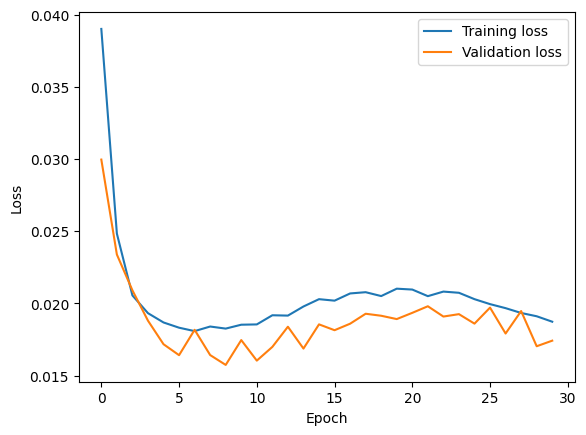

In [156]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [170]:
X_normal_pred = autoencoder.predict(X_normal_seq)
X_anomaly_pred = autoencoder.predict(X_anomaly_seq)


302/302 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [178]:
normal_error = np.mean(
    np.square(X_normal_seq - X_normal_pred),
    axis=(1, 2)
)

anomaly_error = np.mean(
    np.square(X_anomaly_seq - X_anomaly_pred),
    axis=(1, 2)
)
print("MSE normal :", np.mean(normal_error))
print("MSE anomaly :", np.mean(anomaly_error))

MSE normal : 0.028693711427393197
MSE anomaly : 0.13696583750754418


In [172]:
df_normal_with_error = df_encoded_normal.iloc[timesteps-1:].copy()
df_normal_with_error["reconstruction_error"] = normal_error
df_normal_with_error["Machine failure"] = 0


In [173]:
df_anomaly_with_error = df_encoded_anomaly.iloc[timesteps-1:].copy()
df_anomaly_with_error["reconstruction_error"] = anomaly_error
df_anomaly_with_error["Machine failure"] = 1


In [174]:
df_final = pd.concat(
    [df_normal_with_error, df_anomaly_with_error],
    axis=0
).reset_index(drop=True)


In [183]:
threshold = np.percentile(normal_error, 99)

df_final["predicted_anomaly"] = (
    df_final["reconstruction_error"] > threshold
).astype(int)


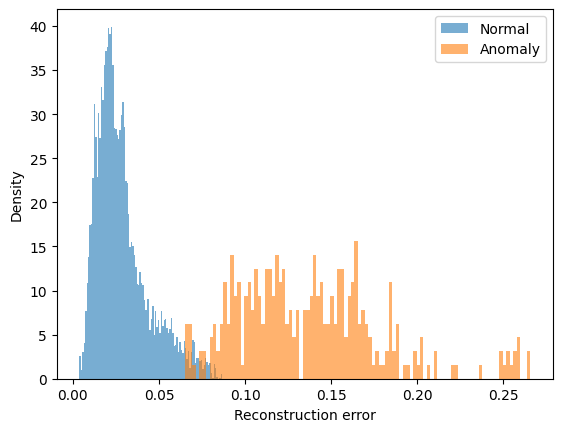

In [184]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.hist(normal_error, bins=100, density=True, alpha=0.6, label="Normal")
plt.hist(anomaly_error, bins=100, density=True, alpha=0.6, label="Anomaly")
plt.xlabel("Reconstruction error")
plt.ylabel("Density")
plt.legend()
plt.show()


**# 8. OPTIMISATION DU SEUIL**

In [ ]:

from sklearn.metrics import recall_score, precision_score, f1_score


y_true = np.concatenate([
    np.zeros(len(normal_error)),  # 0 = Normal
    np.ones(len(anomaly_error))   # 1 = Anomalie
])


all_errors = np.concatenate([normal_error, anomaly_error])
print("\n" + "="*60)
print("OPTIMISATION DU SEUIL (LSTM)")
print("="*60)
results = []
for percentile in [90, 92, 94, 95, 96, 97, 98, 99]:
    threshold = np.percentile(normal_error, percentile)
    predictions = (all_errors > threshold).astype(int)
    
    recall = recall_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    
    results.append({
        'percentile': percentile,
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1
    })
    
    print(f"Seuil {percentile:2d}% ({threshold:.6f}) | Recall: {recall:.3f} | Precision: {precision:.3f} | F1: {f1:.3f}")



OPTIMISATION DU SEUIL (LSTM)
Seuil 90% (0.052424) | Recall: 1.000 | Precision: 0.249 | F1: 0.399
Seuil 92% (0.055719) | Recall: 1.000 | Precision: 0.293 | F1: 0.453
Seuil 94% (0.059406) | Recall: 1.000 | Precision: 0.356 | F1: 0.525
Seuil 95% (0.062050) | Recall: 1.000 | Precision: 0.399 | F1: 0.570
Seuil 96% (0.064717) | Recall: 1.000 | Precision: 0.453 | F1: 0.624
Seuil 97% (0.068588) | Recall: 0.981 | Precision: 0.520 | F1: 0.680
Seuil 98% (0.071483) | Recall: 0.972 | Precision: 0.617 | F1: 0.755
Seuil 99% (0.076683) | Recall: 0.959 | Precision: 0.760 | F1: 0.848


In [189]:
best_result = max(results, key=lambda x: x['f1'])
best_percentile = best_result['percentile']
best_threshold = best_result['threshold']
print(f"\n" + "="*60)
print(f"MEILLEUR SEUIL : {best_percentile}% (Threshold = {best_threshold:.6f})")
print(f"F1-Score : {best_result['f1']:.3f}")
print("="*60)


MEILLEUR SEUIL : 99% (Threshold = 0.076683)
F1-Score : 0.848



              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      9642
    Anomalie       0.76      0.96      0.85       320

    accuracy                           0.99      9962
   macro avg       0.88      0.97      0.92      9962
weighted avg       0.99      0.99      0.99      9962



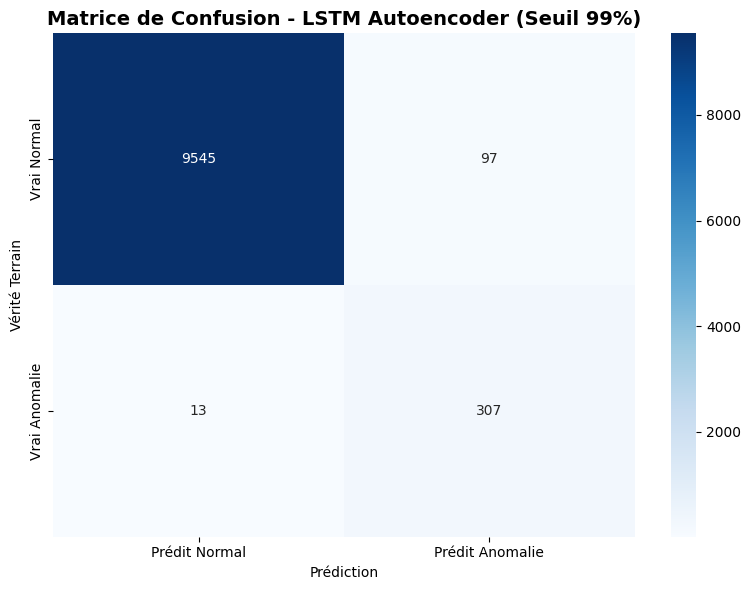

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predictions_best = (all_errors > best_threshold).astype(int)
print("\n" + classification_report(y_true, predictions_best, target_names=['Normal', 'Anomalie']))
cm = confusion_matrix(y_true, predictions_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Anomalie'],
            yticklabels=['Vrai Normal', 'Vrai Anomalie'])
plt.title(f'Matrice de Confusion - LSTM Autoencoder (Seuil {best_percentile}%)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Vérité Terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

**Espace Latent**

In [192]:
from tensorflow.keras.models import Model

# Créer un modèle encoder qui s'arrête à la couche latente
encoder_lstm = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.layers[4].output  
)

# Extraire les représentations latentes
Z_normal_lstm = encoder_lstm.predict(X_normal_seq)
Z_anomaly_lstm = encoder_lstm.predict(X_anomaly_seq)

# Combiner
Z_lstm = np.concatenate([Z_normal_lstm, Z_anomaly_lstm], axis=0)


print(f"Z_normal_lstm shape : {Z_normal_lstm.shape}")
print(f"Z_anomaly_lstm shape : {Z_anomaly_lstm.shape}")
print(f"Z_lstm shape : {Z_lstm.shape}")
print(f"\nDimension de l'espace latent : {Z_lstm.shape[1]}D")

302/302 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Z_normal_lstm shape : (9642, 16)
Z_anomaly_lstm shape : (320, 16)
Z_lstm shape : (9962, 16)

Dimension de l'espace latent : 16D


**PCA**

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=0.90)
Z_lstm_pca = pca.fit_transform(Z_lstm)

print(f"Dimension originale : {Z_lstm.shape[1]}D")
print(f"Dimension réduite : {Z_lstm_pca.shape[1]}D")
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Dimension originale : 16D
Dimension réduite : 3D
Variance totale expliquée : 91.77%


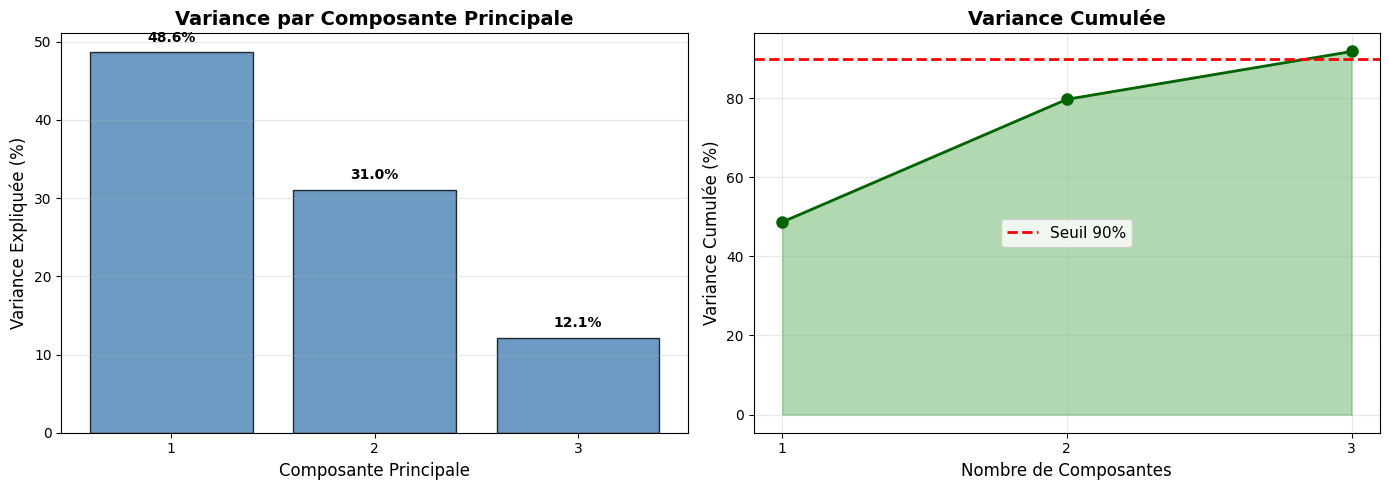


3 composantes retenues pour 90% de variance


In [201]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Barplot de la variance par composante
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance Expliquée (%)', fontsize=12)
axes[0].set_title('Variance par Composante Principale', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Ajouter les valeurs sur les barres
for i, var in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i+1, var*100 + 1, f'{var*100:.1f}%', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Graphique 2 : Variance cumulée
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumulative_variance) + 1), 
             cumulative_variance, 
             marker='o', color='darkgreen', linewidth=2, markersize=8)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=2, label='Seuil 90%')
axes[1].fill_between(range(1, len(cumulative_variance) + 1), 
                      cumulative_variance, alpha=0.3, color='green')
axes[1].set_xlabel('Nombre de Composantes', fontsize=12)
axes[1].set_ylabel('Variance Cumulée (%)', fontsize=12)
axes[1].set_title('Variance Cumulée', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

plt.tight_layout()
plt.show()

print(f"\n{len(pca.explained_variance_ratio_)} composantes retenues pour 90% de variance")

**Visualisation de l'espace latent**

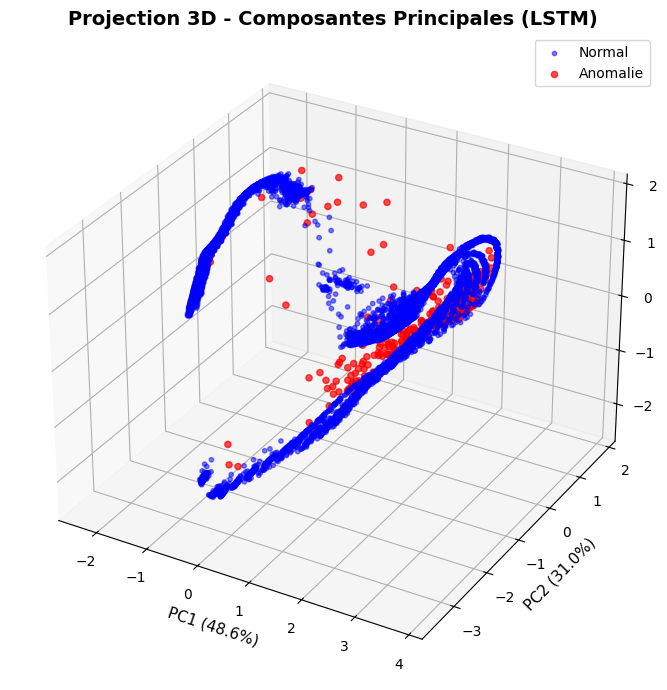

In [210]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Séparer les données
Z_normal_pca = Z_lstm_pca[:len(Z_normal_lstm)]
Z_anomaly_pca = Z_lstm_pca[len(Z_normal_lstm):]

# Créer la figure 3D
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Points normaux (bleu)
ax.scatter(Z_normal_pca[:, 0], Z_normal_pca[:, 1], Z_normal_pca[:, 2],
           c='blue', alpha=0.5, s=10, label='Normal')

# Points anomalies (rouge)
ax.scatter(Z_anomaly_pca[:, 0], Z_anomaly_pca[:, 1], Z_anomaly_pca[:, 2],
           c='red', alpha=0.7, s=20, label='Anomalie')

# Labels
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=11)
ax.set_title('Projection 3D - Composantes Principales (LSTM)', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

**Clustering de l'espace latent**

In [211]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Normaliser l'espace latent PCA
scaler_pca = StandardScaler()
Z_lstm_pca_scaled = scaler_pca.fit_transform(Z_lstm_pca)

# K-Means avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(Z_lstm_pca_scaled)

print("="*60)
print("CLUSTERING K-MEANS (LSTM)")
print("="*60)
print(f"Nombre de clusters : 3")
print(f"\nRépartition des clusters :")
for i in range(3):
    count = np.sum(clusters == i)
    print(f"  Cluster {i} : {count} points ({count/len(clusters)*100:.1f}%)")

CLUSTERING K-MEANS (LSTM)
Nombre de clusters : 3

Répartition des clusters :
  Cluster 0 : 3442 points (34.6%)
  Cluster 1 : 3643 points (36.6%)
  Cluster 2 : 2877 points (28.9%)


**Mesure de la performace du  Kmeans**

In [220]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Normaliser l'espace latent PCA
scaler_pca = StandardScaler()
Z_lstm_pca_scaled = scaler_pca.fit_transform(Z_lstm_pca)

# K-Means avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(Z_lstm_pca_scaled)

print("="*60)
print("CLUSTERING K-MEANS (ESPACE LATENT)")
print("="*60)
print(f"Nombre de clusters : 3")
print(f"\nRépartition des clusters :")
for i in range(3):
    count = np.sum(clusters == i)
    print(f"  Cluster {i} : {count} points ({count/len(clusters)*100:.1f}%)")

CLUSTERING K-MEANS (ESPACE LATENT)
Nombre de clusters : 3

Répartition des clusters :
  Cluster 0 : 3442 points (34.6%)
  Cluster 1 : 3643 points (36.6%)
  Cluster 2 : 2877 points (28.9%)


In [221]:
# Calculer le MSE moyen par cluster
cluster_mse = {}
for c in range(3):
    cluster_mse[c] = all_errors[clusters == c].mean()
    print(f"Cluster {c} | MSE moyenne = {cluster_mse[c]:.6f}")

# Trier par MSE croissant
sorted_clusters = sorted(cluster_mse, key=cluster_mse.get)

# Mapper aux régimes
cluster_to_regime = {
    sorted_clusters[0]: "Normal",
    sorted_clusters[1]: "Dégradé",
    sorted_clusters[2]: "En panne"
}

print("\n" + "="*60)
print("MAPPING CLUSTERS → RÉGIMES")
print("="*60)
for cluster, regime in cluster_to_regime.items():
    print(f"Cluster {cluster} → {regime} (MSE: {cluster_mse[cluster]:.6f})")

# Créer les labels de régimes
regimes = np.array([cluster_to_regime[c] for c in clusters])

Cluster 0 | MSE moyenne = 0.029126
Cluster 1 | MSE moyenne = 0.030181
Cluster 2 | MSE moyenne = 0.038335

MAPPING CLUSTERS → RÉGIMES
Cluster 0 → Normal (MSE: 0.029126)
Cluster 1 → Dégradé (MSE: 0.030181)
Cluster 2 → En panne (MSE: 0.038335)


In [223]:
from sklearn.metrics import silhouette_score

# Calculer le Silhouette Score
silhouette_avg = silhouette_score(Z_lstm_pca_scaled, clusters)

print("="*60)
print("ÉVALUATION DU CLUSTERING (ESPACE LATENT)")
print("="*60)
print(f"Silhouette Score : {silhouette_avg:.3f}")

ÉVALUATION DU CLUSTERING (ESPACE LATENT)
Silhouette Score : 0.549


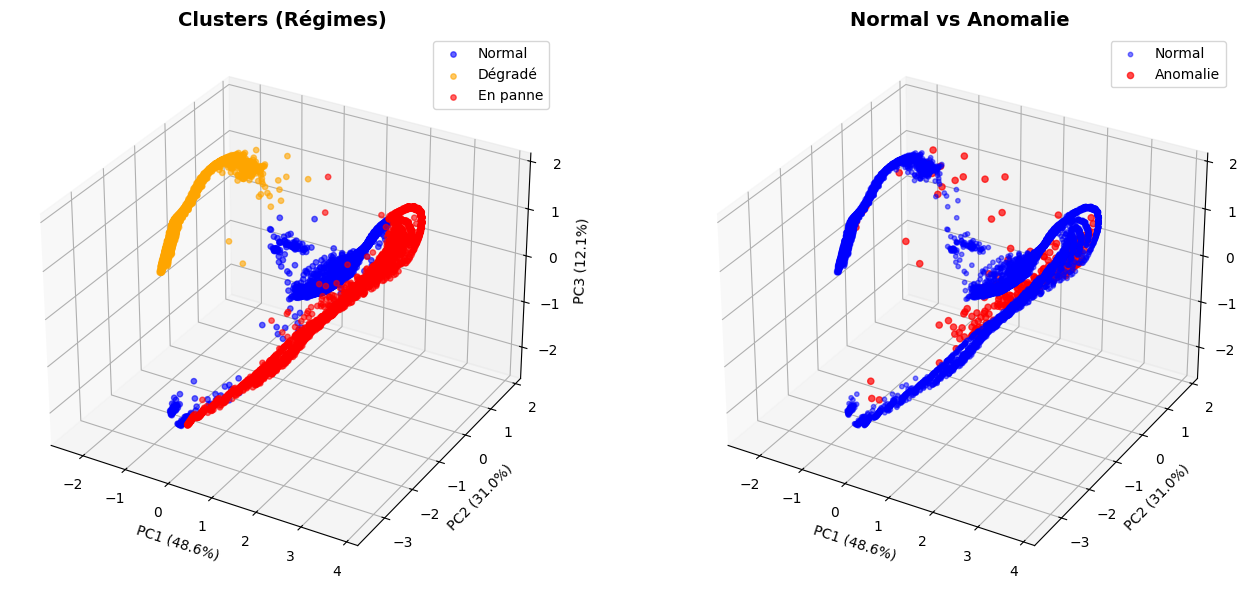


 Clustering terminé : 3 régimes identifiés


In [225]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))

# Subplot 1 : Clusters (régimes)
ax1 = fig.add_subplot(121, projection='3d')
colors = ['blue', 'orange', 'red']
for i, regime in enumerate(['Normal', 'Dégradé', 'En panne']):
    mask = regimes == regime
    ax1.scatter(Z_lstm_pca[mask, 0], Z_lstm_pca[mask, 1], Z_lstm_pca[mask, 2],
                c=colors[i], alpha=0.6, s=15, label=regime)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax1.set_title('Clusters (Régimes)', fontsize=14, fontweight='bold')
ax1.legend()

# Subplot 2 : Normal vs Anomalie
ax2 = fig.add_subplot(122, projection='3d')
Z_normal_pca = Z_lstm_pca[:len(Z_normal_lstm)]
Z_anomaly_pca = Z_lstm_pca[len(Z_normal_lstm):]

ax2.scatter(Z_normal_pca[:, 0], Z_normal_pca[:, 1], Z_normal_pca[:, 2],
            c='blue', alpha=0.5, s=10, label='Normal')
ax2.scatter(Z_anomaly_pca[:, 0], Z_anomaly_pca[:, 1], Z_anomaly_pca[:, 2],
            c='red', alpha=0.7, s=20, label='Anomalie')

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax2.set_title('Normal vs Anomalie', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n Clustering terminé : 3 régimes identifiés")

# 5- Visualisation 

# 6- Interprétation